## Environment and Packages

In [1]:
!nvidia-smi

Tue Jan 27 02:23:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q torch triton 
!pip install -q numpy matplotlib pandas pytest

## Vector Addition

passed
passed
passed
vector-add-performance:
           size      triton       torch
0        4096.0    7.314286    7.384615
1        8192.0   18.285714   19.819355
2       16384.0   41.234899   40.959998
3       32768.0   65.015874   63.999998
4       65536.0  102.828452  104.135590
5      131072.0  149.398175  147.603602
6      262144.0  186.889738  186.535106
7      524288.0  209.046252  207.283078
8     1048576.0  220.042531  219.428568
9     2097152.0  228.017399  227.555555
10    4194304.0  233.709360  233.535863
11    8388608.0  235.229798  235.264975
12   16777216.0  236.877115  237.010968
13   33554432.0  238.592894  238.869176
14   67108864.0  239.608333  239.674513
15  134217728.0  240.542758  240.429580


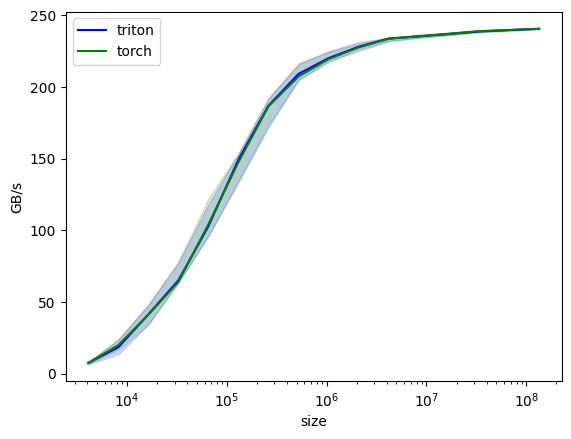

In [3]:
import torch
import triton
import triton.language as tl

DEVICE = torch.device(f'cuda:{torch.cuda.current_device()}')


@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr    # tells triton that this value is known at compile time (constant)
):
    # Which chunk of data are we responsible for?
    PID = tl.program_id(axis=0)
    # vec of length 256
    # BLOCK_SIZE 64
    # PID 0 might process elements [0:64]
    # PID 1 might process elements [64:128]

    block_start = PID * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)  # vec of [0,1,2,...,BLOCK_SIZE-1] + block_start
    mask = offsets < n_elements  # handle case when n_elements is not a multiple of BLOCK_SIZE

    # load data from DRAM/VRAM/HB< to SRAM?on-chip memory
    x = tl.load(x_ptr + offsets, mask=mask, other=None)  # shape (BLOCK_SIZE,)
    y = tl.load(y_ptr + offsets, mask=mask, other=None)

    output = x + y

    # write data back to DRAM
    tl.store(output_ptr + offsets, output, mask=mask)


def add(x, y):
    # pre-allocate the output
    output = torch.empty_like(x)

    # check tensors are on same device
    assert x.device == DEVICE and y.device == DEVICE

    # defining our launch grid (no of programs that will launch in parallel
    n_elements = output.numel()  # total no of elements in that tensor
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)

    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=1024)
    return output


def test_add_kernel(size, atol=1e-3, rtol=1e-3, device=DEVICE):
    # create test data
    torch.manual_seed(0)
    x = torch.randn(size, device=DEVICE)
    y = torch.randn(size, device=DEVICE)
    # run tritom kernel & pytorch equivalent
    z_tri = add(x, y)
    z_ref = x + y
    # compare
    torch.testing.assert_close(z_tri, z_ref, atol=atol, rtol=rtol)
    print('passed')

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # argument names to use as x-axis for the plot
        x_vals=[2**i for i in range(12, 28, 1)],
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['triton', 'torch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='vector-add-performance',
        args={},
    )
)
def benchmark(size, provider):
    # create input data
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)

    quantiles = [0.5, 0.05, 0.95]

    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)  # 3 for read x, read y, write output
    return gbps(ms), gbps(max_ms), gbps(min_ms)


if __name__ == '__main__':
    test_add_kernel(size=4096)
    test_add_kernel(size=4097)
    test_add_kernel(size=98432)

    import sys
    # if len(sys.argv) > 1 and sys.argv[1] == "--benchmark":
        # benchmark.run(save_path='.', print_data=True)
    benchmark.run(save_path='.', print_data=True)